# Etapa Exploratória: Temperatura, Umidade Relativa e Internações Respiratórias

Este notebook tem como objetivo investigar possíveis associações entre a série diária de internações por doenças respiratórias e dois fatores atmosféricos de interesse:

- `temp`: temperatura do ar;
- `ur`: umidade relativa do ar.

Diferentemente de poluentes como `pm2_5`, variáveis meteorológicas costumam apresentar **forte sazonalidade**, possível **não linearidade** e efeitos com **defasagem temporal**. Por isso, a análise aqui combina:

1. visão geral e checagens iniciais;
2. perfis sazonais e mensais;
3. correlações simples e com `lags`;
4. correlações com médias móveis defasadas;
5. dispersões com suavização visual;
6. análise por faixas (quantis), para capturar não linearidade;
7. análise de extremos;
8. correlações após remoção parcial da sazonalidade;
9. análise conjunta de temperatura e umidade (dias frios e secos).

> **Observação metodológica:** resultados de correlação são **exploratórios** e **não implicam causalidade**. Em especial, como internações e variáveis meteorológicas seguem o calendário anual, parte da associação pode refletir sazonalidade compartilhada.


In [1]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


## 2. Configurações iniciais

In [2]:

# Caminhos das bases
AIR_QUALITY_URL = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/DailyQualiarRj/serie_diaria_qualidade_ar_rio_de_janeiro.parquet"
HOSPITALIZATION_URL = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.parquet"

# Colunas principais
AIR_DATE_COLUMN = "data"
HOSP_DATE_COLUMN = "data_dia"
STANDARD_DATE_COLUMN = "data"
TARGET_COLUMN = "num_internacoes"

# Variáveis atmosféricas avaliadas
METEOROLOGICAL_VARIABLES = {
    "temp": "Temperatura do ar",
    "ur": "Umidade relativa do ar",
}

# Parâmetros da análise temporal
MAX_LAG = 21
MOVING_AVERAGE_WINDOWS = [3, 7, 14, 21, 30, 60, 90, 120, 150]
SHIFTS = [1, 7, 14, 21]
MIN_OBS_FOR_CORR = 30
TOP_FEATURES_TO_PLOT = 3
ROLLING_MEAN_WINDOW = 30
FIG_DPI = 120

# Parâmetros para análises adicionais
BIN_QUANTILES = 4
EXTREME_QUANTILE = 0.10

print(f"Variável resposta: {TARGET_COLUMN}")
print(f"Variáveis meteorológicas: {list(METEOROLOGICAL_VARIABLES.keys())}")
print(f"Máximo lag avaliado: {MAX_LAG} dias")
print(f"Janelas de médias móveis: {MOVING_AVERAGE_WINDOWS}")
print(f"Shifts avaliados para médias móveis: {SHIFTS}")


Variável resposta: num_internacoes
Variáveis meteorológicas: ['temp', 'ur']
Máximo lag avaliado: 21 dias
Janelas de médias móveis: [3, 7, 14, 21, 30, 60, 90, 120, 150]
Shifts avaliados para médias móveis: [1, 7, 14, 21]


## 3. Carregamento e preparação dos dados

In [3]:

# Leitura das bases
df_air = pd.read_parquet(AIR_QUALITY_URL).copy()
df_hosp = pd.read_parquet(HOSPITALIZATION_URL).copy()

# Padronização das colunas de data
df_air[AIR_DATE_COLUMN] = pd.to_datetime(df_air[AIR_DATE_COLUMN])
df_hosp[HOSP_DATE_COLUMN] = pd.to_datetime(df_hosp[HOSP_DATE_COLUMN])

df_air = df_air.rename(columns={AIR_DATE_COLUMN: STANDARD_DATE_COLUMN})
df_hosp = df_hosp.rename(columns={HOSP_DATE_COLUMN: STANDARD_DATE_COLUMN})

# Merge por data
selected_air_columns = [STANDARD_DATE_COLUMN] + list(METEOROLOGICAL_VARIABLES.keys())
hospitalizations_and_air = (
    df_hosp[[STANDARD_DATE_COLUMN, TARGET_COLUMN]]
    .merge(
        df_air[selected_air_columns],
        on=STANDARD_DATE_COLUMN,
        how="inner"
    )
    .sort_values(STANDARD_DATE_COLUMN)
    .reset_index(drop=True)
)

# Variáveis de calendário
hospitalizations_and_air["ano"] = hospitalizations_and_air[STANDARD_DATE_COLUMN].dt.year
hospitalizations_and_air["mes"] = hospitalizations_and_air[STANDARD_DATE_COLUMN].dt.month
hospitalizations_and_air["dia_do_ano"] = hospitalizations_and_air[STANDARD_DATE_COLUMN].dt.dayofyear
hospitalizations_and_air["nome_mes"] = hospitalizations_and_air[STANDARD_DATE_COLUMN].dt.month_name(locale="pt_BR.utf8") if False else hospitalizations_and_air[STANDARD_DATE_COLUMN].dt.month

def assign_season_southern_hemisphere(month: int) -> str:
    if month in [12, 1, 2]:
        return "Verão"
    if month in [3, 4, 5]:
        return "Outono"
    if month in [6, 7, 8]:
        return "Inverno"
    return "Primavera"

hospitalizations_and_air["estacao_ano"] = hospitalizations_and_air["mes"].apply(assign_season_southern_hemisphere)

month_labels = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}
hospitalizations_and_air["mes_label"] = hospitalizations_and_air["mes"].map(month_labels)

print("Dimensão da base final:", hospitalizations_and_air.shape)
display(hospitalizations_and_air.head())


Dimensão da base final: (2557, 10)


,data,num_internacoes,temp,ur,ano,mes,dia_do_ano,nome_mes,estacao_ano,mes_label
0,2012-01-01,490,25.556,92.521,2012,1,1,1,Verão,Jan
1,2012-01-02,672,22.264,95.074,2012,1,2,1,Verão,Jan
2,2012-01-03,462,25.091,73.642,2012,1,3,1,Verão,Jan
3,2012-01-04,490,26.083,72.631,2012,1,4,1,Verão,Jan
4,2012-01-05,378,26.661,74.860,2012,1,5,1,Verão,Jan


## 4. Checagens iniciais de qualidade

In [4]:

quality_summary = pd.DataFrame({
    "dtype": hospitalizations_and_air.dtypes.astype(str),
    "missing_count": hospitalizations_and_air.isna().sum(),
    "missing_pct": (hospitalizations_and_air.isna().mean() * 100).round(2),
    "n_unique": hospitalizations_and_air.nunique()
}).reset_index(names="column")

display(quality_summary)

duplicated_dates = hospitalizations_and_air[STANDARD_DATE_COLUMN].duplicated().sum()
print(f"Datas duplicadas: {duplicated_dates}")
print(f"Período analisado: {hospitalizations_and_air[STANDARD_DATE_COLUMN].min().date()} até {hospitalizations_and_air[STANDARD_DATE_COLUMN].max().date()}")


,column,dtype,missing_count,missing_pct,n_unique
0,data,datetime64[us],0,0.0,2557
1,num_internacoes,int64,0,0.0,540
2,temp,float64,23,0.9,2272
3,ur,float64,23,0.9,2446
4,ano,int32,0,0.0,7
5,mes,int32,0,0.0,12
6,dia_do_ano,int32,0,0.0,366
7,nome_mes,int32,0,0.0,12
8,estacao_ano,str,0,0.0,4
9,mes_label,str,0,0.0,12


Datas duplicadas: 0
Período analisado: 2012-01-01 até 2018-12-31


## 5. Visão geral das séries

,count,mean,std,min,5%,25%,50%,75%,95%,max
num_internacoes,2557.0,370.944,185.704,48.000,135.000,234.000,340.000,468.000,716.000,1218.000
temp,2534.0,26.032,3.302,15.897,20.860,23.595,25.818,28.436,31.579,35.313
ur,2534.0,69.889,10.086,40.722,52.596,63.015,69.986,76.563,87.584,97.247


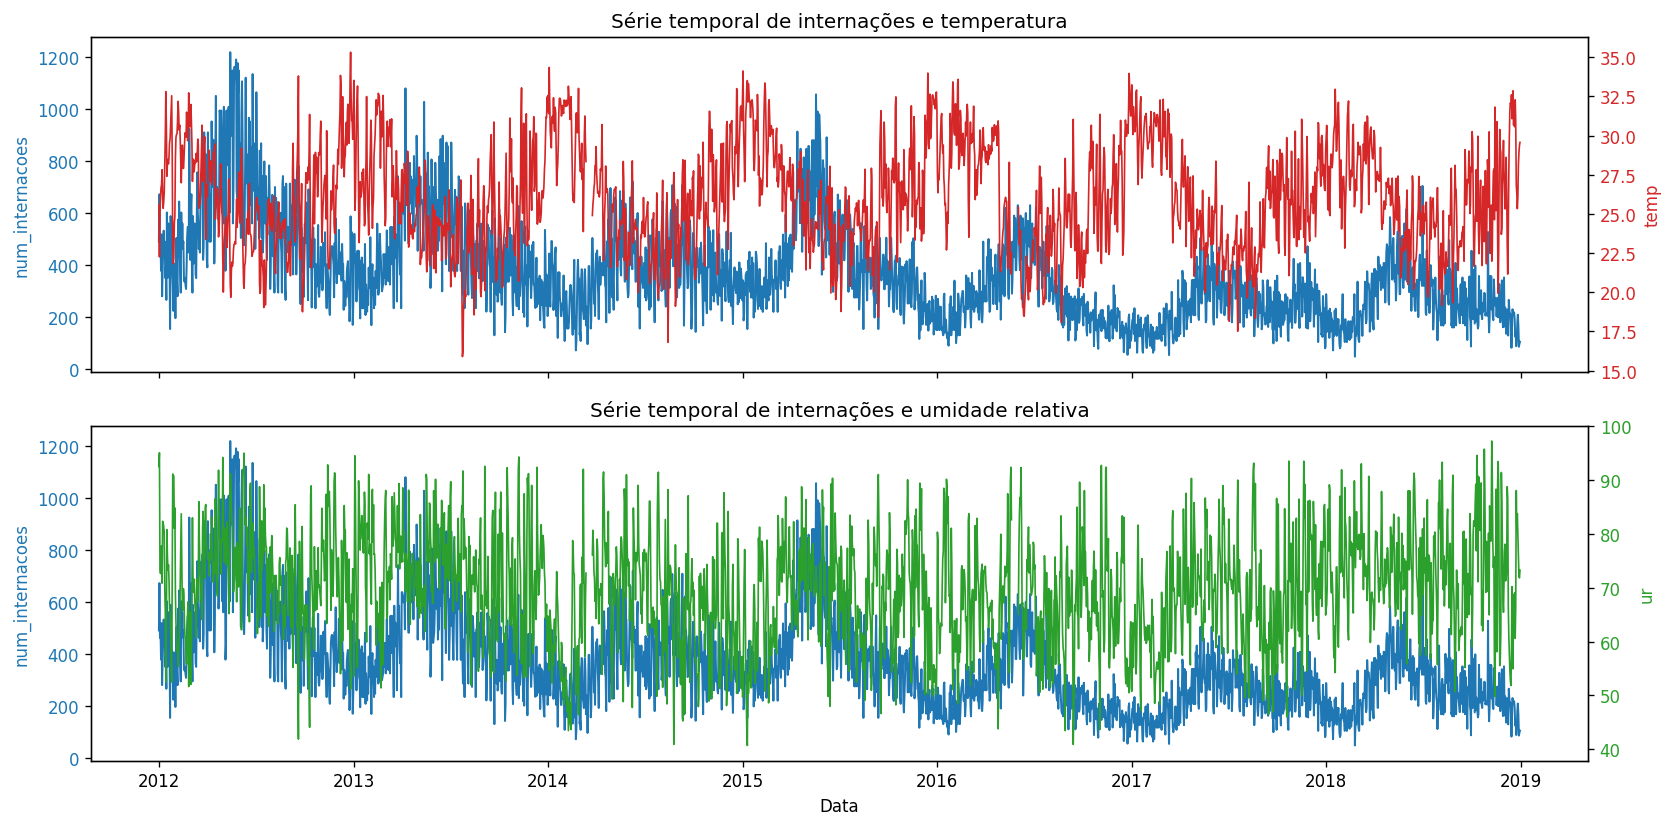

In [5]:

descriptive_columns = [TARGET_COLUMN] + list(METEOROLOGICAL_VARIABLES.keys())

display(
    hospitalizations_and_air[descriptive_columns]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T
    .round(3)
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 7),
    dpi=FIG_DPI,
    sharex=True
)

# Temperatura
ax1 = axes[0]
ax1.plot(
    hospitalizations_and_air[STANDARD_DATE_COLUMN],
    hospitalizations_and_air[TARGET_COLUMN],
    color="tab:blue",
    linewidth=1.2,
    label=TARGET_COLUMN
)
ax1.set_ylabel(TARGET_COLUMN, color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax1b = ax1.twinx()
ax1b.plot(
    hospitalizations_and_air[STANDARD_DATE_COLUMN],
    hospitalizations_and_air["temp"],
    color="tab:red",
    linewidth=1.0,
    label="temp"
)
ax1b.set_ylabel("temp", color="tab:red")
ax1b.tick_params(axis="y", labelcolor="tab:red")
ax1.set_title("Série temporal de internações e temperatura")

# Umidade relativa
ax2 = axes[1]
ax2.plot(
    hospitalizations_and_air[STANDARD_DATE_COLUMN],
    hospitalizations_and_air[TARGET_COLUMN],
    color="tab:blue",
    linewidth=1.2,
    label=TARGET_COLUMN
)
ax2.set_ylabel(TARGET_COLUMN, color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

ax2b = ax2.twinx()
ax2b.plot(
    hospitalizations_and_air[STANDARD_DATE_COLUMN],
    hospitalizations_and_air["ur"],
    color="tab:green",
    linewidth=1.0,
    label="ur"
)
ax2b.set_ylabel("ur", color="tab:green")
ax2b.tick_params(axis="y", labelcolor="tab:green")
ax2.set_title("Série temporal de internações e umidade relativa")
ax2.set_xlabel("Data")

plt.tight_layout()
plt.show()


## 6. Perfis sazonais e mensais

Como temperatura, umidade e internações podem compartilhar um calendário anual, esta etapa ajuda a distinguir padrões sazonais amplos antes de partir para correlações simples.


### Médias por estação do ano

,num_internacoes,temp,ur
estacao_ano,,,
Verão,266.041,29.175,66.759
Outono,457.773,26.211,72.363
Inverno,437.233,23.195,71.109
Primavera,320.224,25.604,69.349


### Médias mensais

,mes_label,num_internacoes,temp,ur
0,Jan,271.101,29.137,67.956
1,Fev,270.717,29.669,64.556
2,Mar,336.912,28.058,72.045
3,Abr,483.038,26.450,71.935
4,Mai,554.184,24.119,73.116
5,Jun,497.286,23.350,74.247
6,Jul,441.092,22.969,71.028
7,Ago,375.258,23.272,68.168
8,Set,340.214,24.895,66.905
9,Out,314.253,25.788,68.948


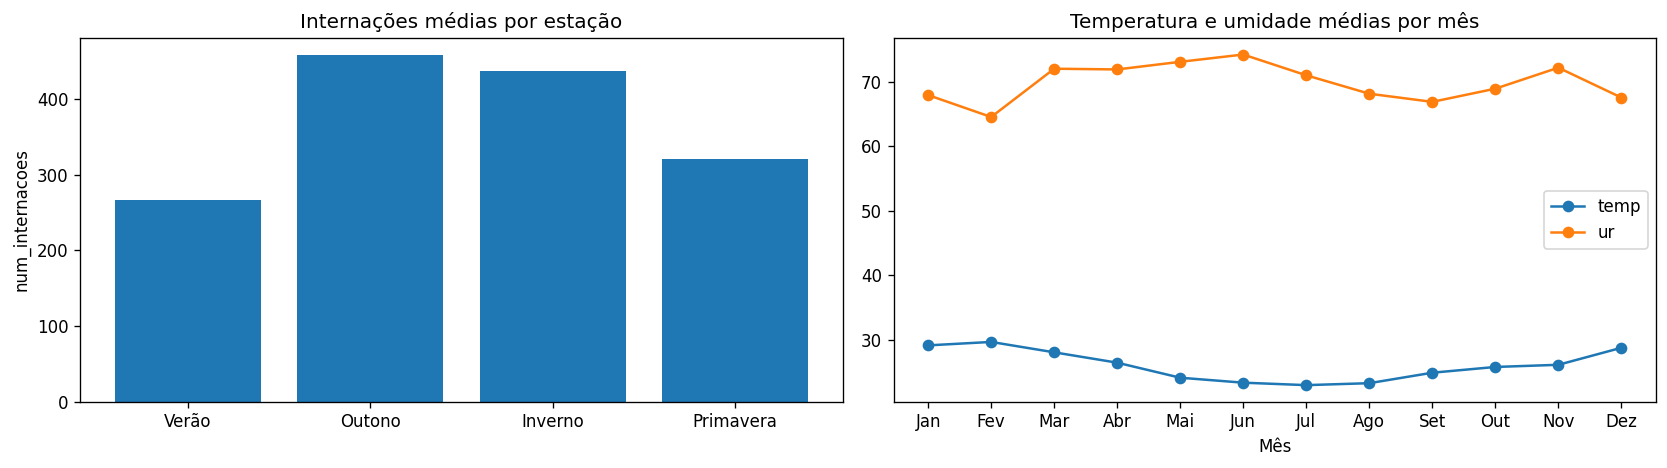

In [6]:

season_order = ["Verão", "Outono", "Inverno", "Primavera"]

seasonal_profile = (
    hospitalizations_and_air
    .groupby("estacao_ano")[[TARGET_COLUMN, "temp", "ur"]]
    .mean()
    .reindex(season_order)
    .round(3)
)

monthly_profile = (
    hospitalizations_and_air
    .groupby(["mes", "mes_label"])[[TARGET_COLUMN, "temp", "ur"]]
    .mean()
    .reset_index()
    .sort_values("mes")
)

display(Markdown("### Médias por estação do ano"))
display(seasonal_profile)

display(Markdown("### Médias mensais"))
display(monthly_profile[["mes_label", TARGET_COLUMN, "temp", "ur"]].round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=FIG_DPI)

axes[0].bar(seasonal_profile.index, seasonal_profile[TARGET_COLUMN])
axes[0].set_title("Internações médias por estação")
axes[0].set_ylabel(TARGET_COLUMN)

axes[1].plot(monthly_profile["mes_label"], monthly_profile["temp"], marker="o", label="temp")
axes[1].plot(monthly_profile["mes_label"], monthly_profile["ur"], marker="o", label="ur")
axes[1].set_title("Temperatura e umidade médias por mês")
axes[1].set_xlabel("Mês")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Funções auxiliares

In [7]:

def safe_corr(series_x, series_y, method="pearson", min_obs=30):
    valid_df = pd.concat([series_x, series_y], axis=1).dropna()
    if len(valid_df) < min_obs:
        return np.nan, len(valid_df)
    value = valid_df.iloc[:, 0].corr(valid_df.iloc[:, 1], method=method)
    return value, len(valid_df)


def add_smooth_curve(ax, x, y, window=60):
    plot_df = pd.DataFrame({"x": x, "y": y}).dropna().sort_values("x")
    if len(plot_df) < max(window, 10):
        return
    smoothed = plot_df["y"].rolling(window=window, min_periods=max(10, window // 5)).mean()
    ax.plot(plot_df["x"], smoothed, linewidth=2.0, linestyle="--")


def create_time_features(df, variable, max_lag, windows, shifts):
    analysis_df = df[[STANDARD_DATE_COLUMN, TARGET_COLUMN, variable]].copy()

    feature_columns = []

    # Lags simples
    for lag in range(0, max_lag + 1):
        column_name = f"{variable}_lag_{lag}"
        analysis_df[column_name] = analysis_df[variable].shift(lag)
        feature_columns.append(column_name)

    # Médias móveis defasadas
    for window in windows:
        for shift in shifts:
            column_name = f"{variable}_ma_{window}_shift_{shift}"
            analysis_df[column_name] = (
                analysis_df[variable]
                .shift(shift)
                .rolling(window=window, min_periods=window)
                .mean()
            )
            feature_columns.append(column_name)

    return analysis_df, feature_columns


def evaluate_features(analysis_df, variable, feature_columns, min_obs=30):
    results = []

    for feature in feature_columns:
        pearson_corr, n_obs_pearson = safe_corr(
            analysis_df[TARGET_COLUMN],
            analysis_df[feature],
            method="pearson",
            min_obs=min_obs
        )
        spearman_corr, n_obs_spearman = safe_corr(
            analysis_df[TARGET_COLUMN],
            analysis_df[feature],
            method="spearman",
            min_obs=min_obs
        )

        feature_type = "lag" if "_lag_" in feature else "moving_average"
        lag_value = np.nan
        window_value = np.nan
        shift_value = np.nan

        lag_match = re.search(r"_lag_(\d+)$", feature)
        if lag_match:
            lag_value = int(lag_match.group(1))

        ma_match = re.search(r"_ma_(\d+)_shift_(\d+)$", feature)
        if ma_match:
            window_value = int(ma_match.group(1))
            shift_value = int(ma_match.group(2))

        results.append({
            "variable": variable,
            "feature": feature,
            "feature_type": feature_type,
            "lag": lag_value,
            "window": window_value,
            "shift": shift_value,
            "pearson_corr": pearson_corr,
            "spearman_corr": spearman_corr,
            "abs_pearson_corr": abs(pearson_corr) if pd.notna(pearson_corr) else np.nan,
            "abs_spearman_corr": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan,
            "n_obs": max(n_obs_pearson, n_obs_spearman),
        })

    return pd.DataFrame(results)


def build_quantile_analysis(df, variable, n_quantiles=4):
    valid_df = df[[TARGET_COLUMN, variable]].dropna().copy()
    valid_df["faixa"] = pd.qcut(valid_df[variable], q=n_quantiles, duplicates="drop")
    summary = (
        valid_df
        .groupby("faixa")
        .agg(
            n_obs=(TARGET_COLUMN, "size"),
            media_internacoes=(TARGET_COLUMN, "mean"),
            mediana_internacoes=(TARGET_COLUMN, "median"),
            media_variavel=(variable, "mean"),
        )
        .reset_index()
    )
    return summary


def build_extreme_analysis(df, variable, lower_quantile=0.10):
    threshold = df[variable].quantile(lower_quantile)
    valid_df = df[[STANDARD_DATE_COLUMN, TARGET_COLUMN, variable]].dropna().copy()
    valid_df["evento_extremo_baixo"] = valid_df[variable] <= threshold

    summary = (
        valid_df
        .groupby("evento_extremo_baixo")
        .agg(
            n_obs=(TARGET_COLUMN, "size"),
            media_internacoes=(TARGET_COLUMN, "mean"),
            mediana_internacoes=(TARGET_COLUMN, "median"),
            media_variavel=(variable, "mean"),
        )
        .reset_index()
    )
    summary["limiar_extremo"] = threshold
    return summary, threshold


def create_monthly_anomalies(df, variable):
    anomaly_df = df[[STANDARD_DATE_COLUMN, TARGET_COLUMN, variable, "mes"]].copy()
    anomaly_df[f"{variable}_anomalia_mensal"] = (
        anomaly_df[variable] - anomaly_df.groupby("mes")[variable].transform("mean")
    )
    anomaly_df[f"{TARGET_COLUMN}_anomalia_mensal"] = (
        anomaly_df[TARGET_COLUMN] - anomaly_df.groupby("mes")[TARGET_COLUMN].transform("mean")
    )
    return anomaly_df


def summarize_best_results(results_df, variable_label):
    if results_df.empty:
        return f"Não houve resultados suficientes para {variable_label}."

    valid_results = results_df.dropna(subset=["abs_pearson_corr"]).copy()
    if valid_results.empty:
        return f"Não houve observações suficientes para estimar correlações de {variable_label}."

    best_row = valid_results.sort_values("abs_pearson_corr", ascending=False).iloc[0]

    if best_row["feature_type"] == "lag":
        feature_desc = f"lag = {int(best_row['lag'])}"
    else:
        feature_desc = f"janela = {int(best_row['window'])}, shift = {int(best_row['shift'])}"

    direction = "positiva" if best_row["pearson_corr"] >= 0 else "negativa"

    return (
        f"Para **{variable_label}**, a maior correlação absoluta de Pearson apareceu em "
        f"**{feature_desc}**, com correlação **{direction}** de "
        f"**{best_row['pearson_corr']:.3f}** (n = {int(best_row['n_obs'])})."
    )


## 8. Correlações, lags e médias móveis defasadas

A célula abaixo executa a análise principal para `temp` e `ur`, mantendo a mesma lógica para ambas as variáveis.


## Análise de `temp` — Temperatura do ar

### Top associações por correlação absoluta de Pearson

,feature,feature_type,lag,window,shift,pearson_corr,spearman_corr,n_obs
0,temp_ma_14_shift_1,moving_average,NaN,14.0,1.0,-0.3045,-0.3182,2494
1,temp_ma_7_shift_1,moving_average,NaN,7.0,1.0,-0.2922,-0.3076,2515
2,temp_ma_21_shift_1,moving_average,NaN,21.0,1.0,-0.2896,-0.3050,2473
3,temp_ma_7_shift_7,moving_average,NaN,7.0,7.0,-0.2867,-0.3010,2509
4,temp_ma_14_shift_7,moving_average,NaN,14.0,7.0,-0.2734,-0.2907,2488
5,temp_ma_3_shift_7,moving_average,NaN,3.0,7.0,-0.2716,-0.2838,2521
6,temp_ma_30_shift_1,moving_average,NaN,30.0,1.0,-0.2635,-0.2790,2446
7,temp_ma_150_shift_21,moving_average,NaN,150.0,21.0,0.2630,0.2086,2066
8,temp_lag_6,lag,6.0,NaN,NaN,-0.2586,-0.2721,2528
9,temp_lag_7,lag,7.0,NaN,NaN,-0.2579,-0.2709,2527


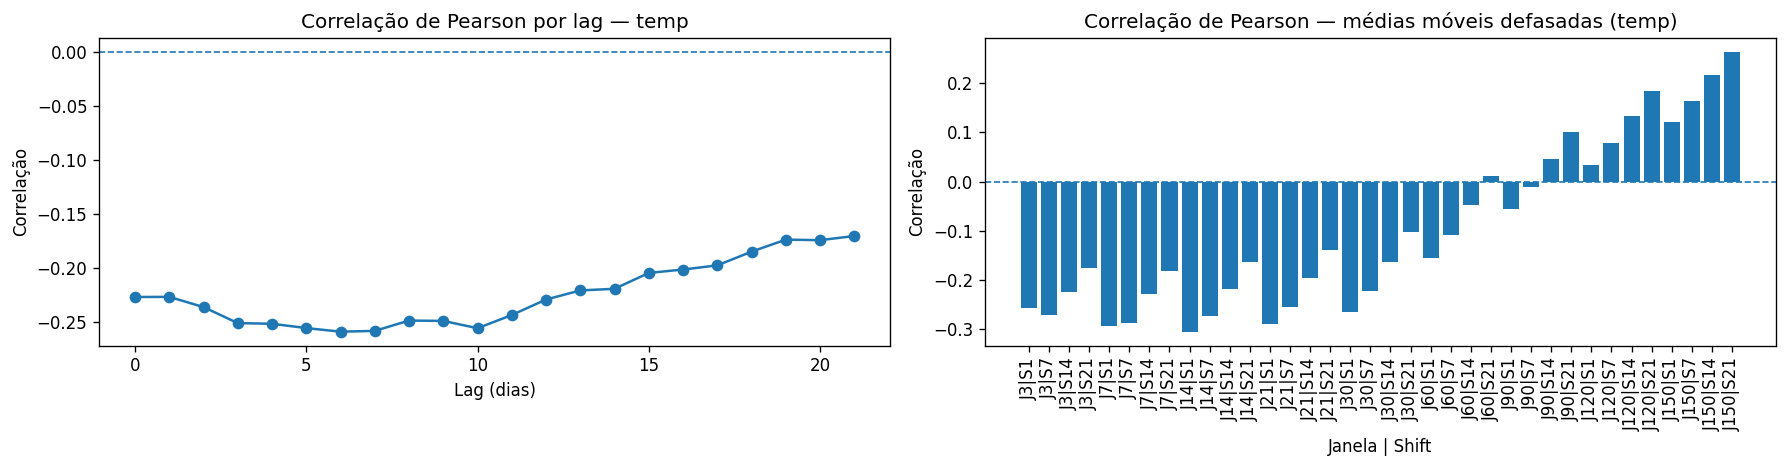

Para **Temperatura do ar**, a maior correlação absoluta de Pearson apareceu em **janela = 14, shift = 1**, com correlação **negativa** de **-0.304** (n = 2494).

## Análise de `ur` — Umidade relativa do ar

### Top associações por correlação absoluta de Pearson

,feature,feature_type,lag,window,shift,pearson_corr,spearman_corr,n_obs
0,ur_ma_60_shift_1,moving_average,NaN,60.0,1.0,0.3942,0.3408,2356
1,ur_ma_60_shift_7,moving_average,NaN,60.0,7.0,0.3805,0.3341,2350
2,ur_ma_90_shift_1,moving_average,NaN,90.0,1.0,0.3787,0.3450,2266
3,ur_ma_30_shift_7,moving_average,NaN,30.0,7.0,0.3738,0.3158,2440
4,ur_ma_30_shift_1,moving_average,NaN,30.0,1.0,0.3679,0.3095,2446
5,ur_ma_90_shift_7,moving_average,NaN,90.0,7.0,0.3623,0.3375,2260
6,ur_ma_30_shift_14,moving_average,NaN,30.0,14.0,0.3581,0.3056,2433
7,ur_ma_60_shift_14,moving_average,NaN,60.0,14.0,0.3542,0.3177,2343
8,ur_ma_120_shift_1,moving_average,NaN,120.0,1.0,0.3538,0.3513,2176
9,ur_ma_21_shift_7,moving_average,NaN,21.0,7.0,0.3530,0.2959,2467


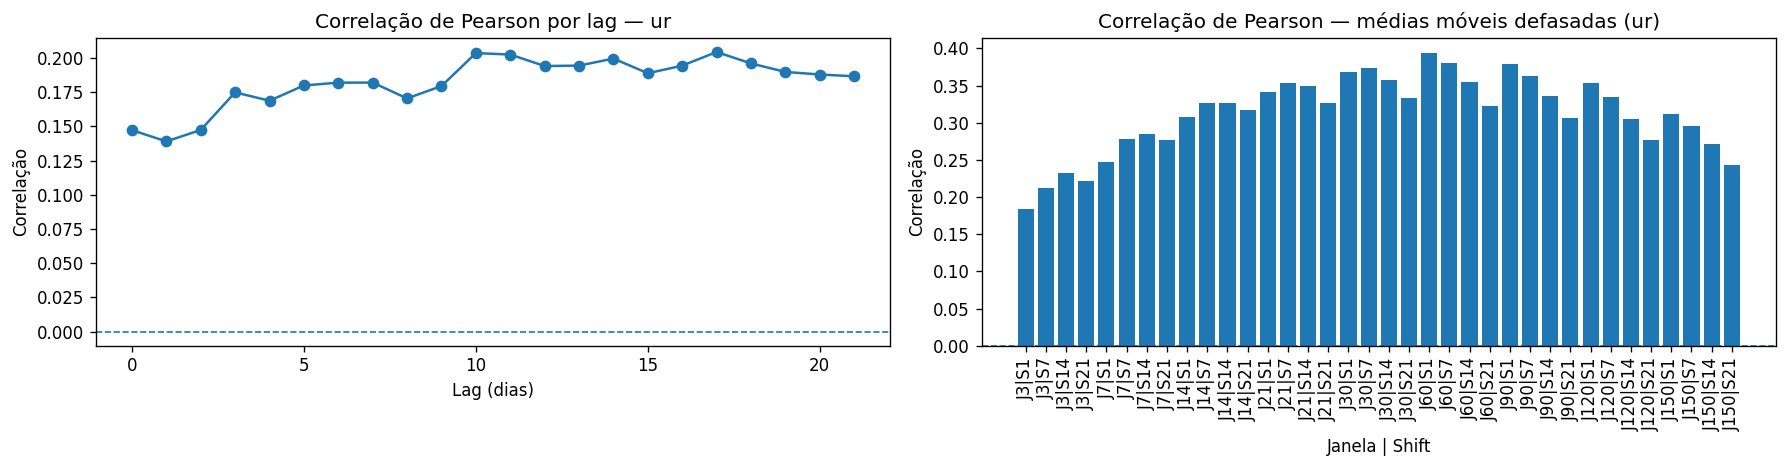

Para **Umidade relativa do ar**, a maior correlação absoluta de Pearson apareceu em **janela = 60, shift = 1**, com correlação **positiva** de **0.394** (n = 2356).

In [8]:

analysis_results = {}

for variable, variable_label in METEOROLOGICAL_VARIABLES.items():
    display(Markdown(f"## Análise de `{variable}` — {variable_label}"))

    analysis_df, feature_columns = create_time_features(
        df=hospitalizations_and_air,
        variable=variable,
        max_lag=MAX_LAG,
        windows=MOVING_AVERAGE_WINDOWS,
        shifts=SHIFTS
    )

    results_df = evaluate_features(
        analysis_df=analysis_df,
        variable=variable,
        feature_columns=feature_columns,
        min_obs=MIN_OBS_FOR_CORR
    ).sort_values("abs_pearson_corr", ascending=False).reset_index(drop=True)

    analysis_results[variable] = {
        "analysis_df": analysis_df,
        "feature_columns": feature_columns,
        "results_df": results_df,
    }

    display(Markdown("### Top associações por correlação absoluta de Pearson"))
    display(
        results_df[
            ["feature", "feature_type", "lag", "window", "shift", "pearson_corr", "spearman_corr", "n_obs"]
        ]
        .head(10)
        .round(4)
    )

    lag_results = (
        results_df[results_df["feature_type"] == "lag"]
        .sort_values("lag")
        .reset_index(drop=True)
    )

    ma_results = (
        results_df[results_df["feature_type"] == "moving_average"]
        .sort_values(["window", "shift"])
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 4), dpi=FIG_DPI)

    axes[0].plot(lag_results["lag"], lag_results["pearson_corr"], marker="o")
    axes[0].axhline(0, linestyle="--", linewidth=1)
    axes[0].set_title(f"Correlação de Pearson por lag — {variable}")
    axes[0].set_xlabel("Lag (dias)")
    axes[0].set_ylabel("Correlação")

    if not ma_results.empty:
        ma_plot = ma_results.copy()
        ma_plot["label"] = ma_plot.apply(
            lambda row: f"J{int(row['window'])}|S{int(row['shift'])}",
            axis=1
        )
        axes[1].bar(ma_plot["label"], ma_plot["pearson_corr"])
        axes[1].axhline(0, linestyle="--", linewidth=1)
        axes[1].set_title(f"Correlação de Pearson — médias móveis defasadas ({variable})")
        axes[1].set_xlabel("Janela | Shift")
        axes[1].set_ylabel("Correlação")
        axes[1].tick_params(axis="x", rotation=90)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()

    display(Markdown(summarize_best_results(results_df, variable_label)))


## 9. Dispersão das combinações mais relevantes

Como a relação entre internações e variáveis meteorológicas pode não ser linear, vale inspecionar visualmente as combinações mais promissoras.


## Dispersão — `temp` (Temperatura do ar)

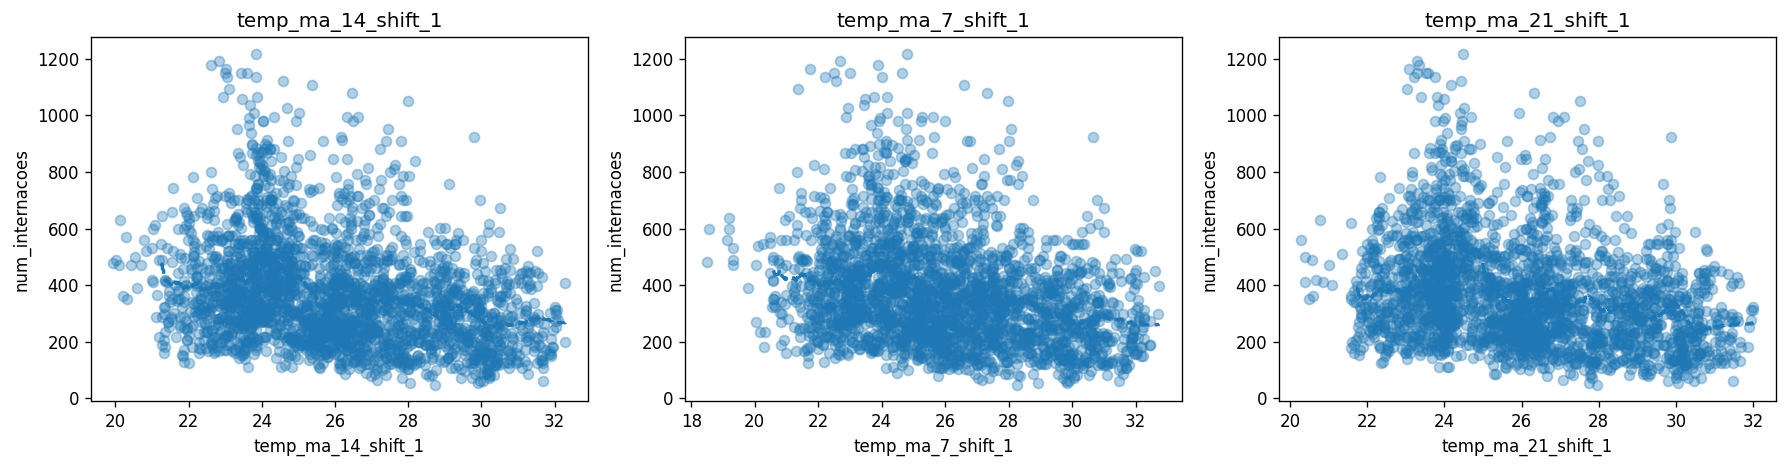

## Dispersão — `ur` (Umidade relativa do ar)

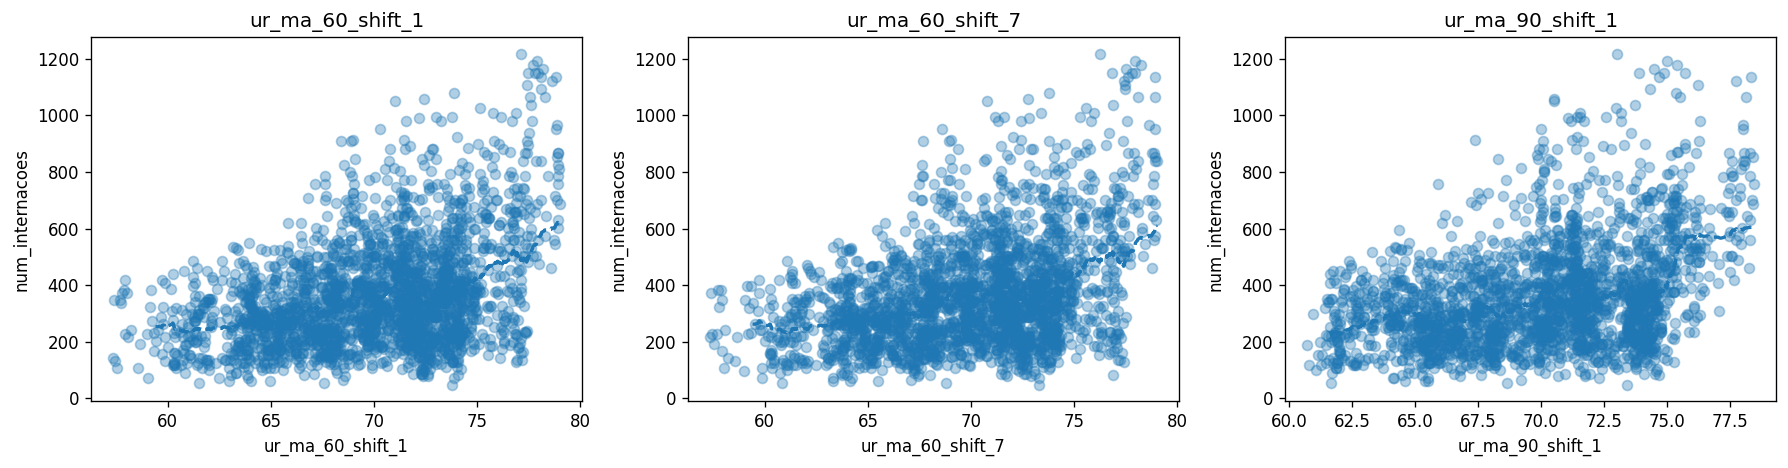

In [9]:

for variable, variable_label in METEOROLOGICAL_VARIABLES.items():
    display(Markdown(f"## Dispersão — `{variable}` ({variable_label})"))

    analysis_df = analysis_results[variable]["analysis_df"]
    results_df = analysis_results[variable]["results_df"]

    top_features = (
        results_df
        .dropna(subset=["abs_pearson_corr"])
        .head(TOP_FEATURES_TO_PLOT)["feature"]
        .tolist()
    )

    if not top_features:
        print("Sem features suficientes para plotar.")
        continue

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(top_features),
        figsize=(5 * len(top_features), 4),
        dpi=FIG_DPI
    )

    if len(top_features) == 1:
        axes = [axes]

    for ax, feature in zip(axes, top_features):
        plot_df = analysis_df[[TARGET_COLUMN, feature]].dropna().copy()

        ax.scatter(plot_df[feature], plot_df[TARGET_COLUMN], alpha=0.35)
        add_smooth_curve(ax, plot_df[feature], plot_df[TARGET_COLUMN], window=max(30, len(plot_df)//20))
        ax.set_title(feature)
        ax.set_xlabel(feature)
        ax.set_ylabel(TARGET_COLUMN)

    plt.tight_layout()
    plt.show()


## 10. Análise por estação do ano

Aqui verificamos se a associação se mantém quando os dados são analisados separadamente por estação. Isso ajuda a avaliar se a correlação global está sendo puxada apenas pela sazonalidade anual.


,variable,variable_label,estacao_ano,pearson_corr,spearman_corr,n_obs
0,temp,Temperatura do ar,Verão,0.0540,0.0520,632
1,temp,Temperatura do ar,Outono,-0.2703,-0.2708,622
2,temp,Temperatura do ar,Inverno,0.1043,0.0900,643
3,temp,Temperatura do ar,Primavera,0.0658,0.0416,637
4,ur,Umidade relativa do ar,Verão,-0.0013,-0.0208,632
5,ur,Umidade relativa do ar,Outono,0.1690,0.1551,622
6,ur,Umidade relativa do ar,Inverno,0.1368,0.1359,643
7,ur,Umidade relativa do ar,Primavera,-0.0608,-0.0265,637


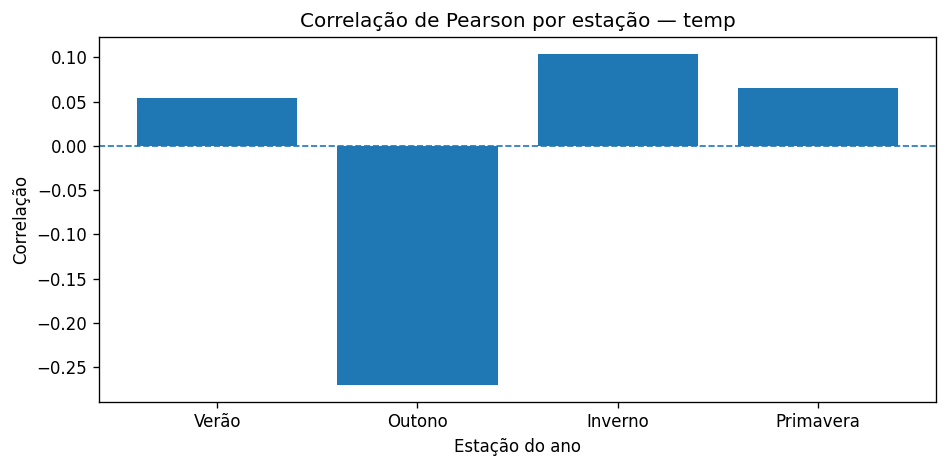

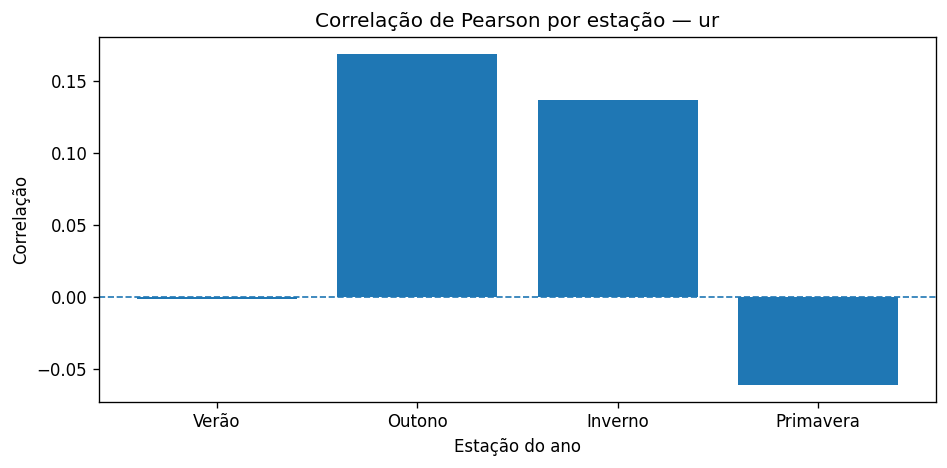

In [10]:

seasonal_correlation_rows = []

for variable, variable_label in METEOROLOGICAL_VARIABLES.items():
    for season in season_order:
        season_df = hospitalizations_and_air.loc[
            hospitalizations_and_air["estacao_ano"] == season,
            [TARGET_COLUMN, variable]
        ].dropna()

        pearson_corr, n_obs = safe_corr(
            season_df[TARGET_COLUMN],
            season_df[variable],
            method="pearson",
            min_obs=MIN_OBS_FOR_CORR
        )
        spearman_corr, _ = safe_corr(
            season_df[TARGET_COLUMN],
            season_df[variable],
            method="spearman",
            min_obs=MIN_OBS_FOR_CORR
        )

        seasonal_correlation_rows.append({
            "variable": variable,
            "variable_label": variable_label,
            "estacao_ano": season,
            "pearson_corr": pearson_corr,
            "spearman_corr": spearman_corr,
            "n_obs": n_obs,
        })

seasonal_corr_df = pd.DataFrame(seasonal_correlation_rows)
display(seasonal_corr_df.round(4))

for variable in METEOROLOGICAL_VARIABLES.keys():
    plot_df = seasonal_corr_df[seasonal_corr_df["variable"] == variable]
    plt.figure(figsize=(8, 4), dpi=FIG_DPI)
    plt.bar(plot_df["estacao_ano"], plot_df["pearson_corr"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Correlação de Pearson por estação — {variable}")
    plt.xlabel("Estação do ano")
    plt.ylabel("Correlação")
    plt.tight_layout()
    plt.show()


## 11. Análise por faixas da variável atmosférica

Esta etapa organiza a variável em quantis e compara o nível médio de internações entre as faixas. Isso pode revelar padrões não lineares que uma correlação simples não capta bem.


## Faixas por quantis — `temp` (Temperatura do ar)

,faixa,n_obs,media_internacoes,mediana_internacoes,media_variavel
0,"(15.896, 23.595]",635,404.150,372.0,21.914
1,"(23.595, 25.818]",632,417.582,376.5,24.722
2,"(25.818, 28.436]",633,364.207,340.0,27.068
3,"(28.436, 35.313]",634,298.003,275.5,30.429


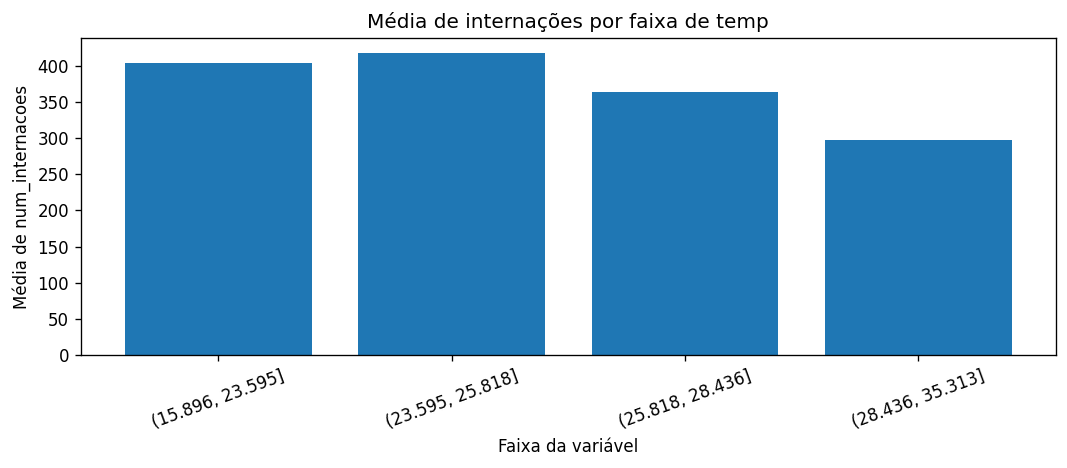

## Faixas por quantis — `ur` (Umidade relativa do ar)

,faixa,n_obs,media_internacoes,mediana_internacoes,media_variavel
0,"(40.721000000000004, 63.015]",634,320.726,307.5,56.867
1,"(63.015, 69.986]",633,365.458,341.0,66.823
2,"(69.986, 76.563]",633,404.082,361.0,73.163
3,"(76.563, 97.247]",634,393.636,350.0,82.705


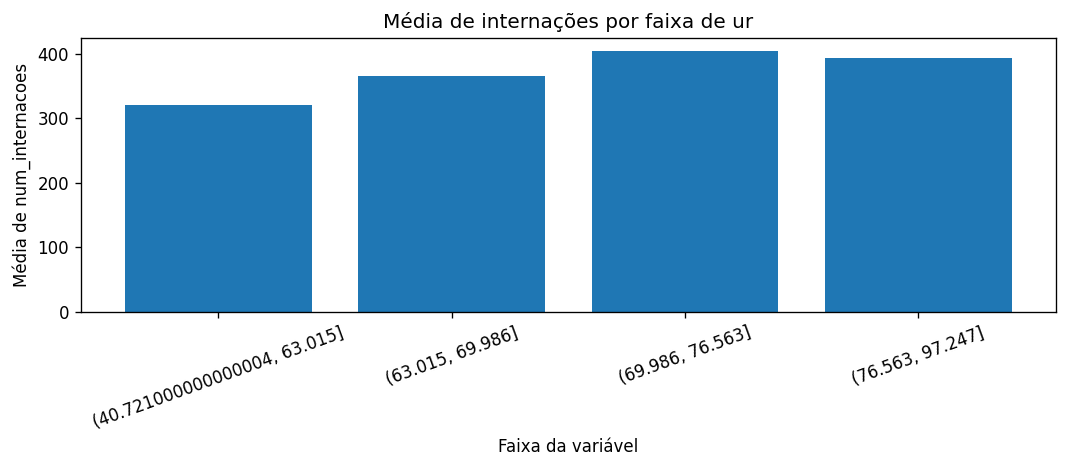

In [11]:

quantile_results = {}

for variable, variable_label in METEOROLOGICAL_VARIABLES.items():
    display(Markdown(f"## Faixas por quantis — `{variable}` ({variable_label})"))

    summary = build_quantile_analysis(
        df=hospitalizations_and_air,
        variable=variable,
        n_quantiles=BIN_QUANTILES
    )
    quantile_results[variable] = summary

    display(summary.round(3))

    plt.figure(figsize=(9, 4), dpi=FIG_DPI)
    plt.bar(summary["faixa"].astype(str), summary["media_internacoes"])
    plt.title(f"Média de internações por faixa de {variable}")
    plt.xlabel("Faixa da variável")
    plt.ylabel(f"Média de {TARGET_COLUMN}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


## 12. Análise de extremos

Aqui são comparados os dias em que a variável está nos valores mais baixos (`p10`) com os demais dias. Para temperatura, isso ajuda a examinar períodos mais frios. Para umidade, ajuda a examinar dias mais secos.


In [12]:

extreme_results = {}

for variable, variable_label in METEOROLOGICAL_VARIABLES.items():
    display(Markdown(f"## Extremos inferiores — `{variable}` ({variable_label})"))

    summary, threshold = build_extreme_analysis(
        df=hospitalizations_and_air,
        variable=variable,
        lower_quantile=EXTREME_QUANTILE
    )
    extreme_results[variable] = summary

    print(f"Limiar do percentil {int(EXTREME_QUANTILE * 100)} para {variable}: {threshold:.3f}")
    display(summary.round(3))


## Extremos inferiores — `temp` (Temperatura do ar)

Limiar do percentil 10 para temp: 21.814


,evento_extremo_baixo,n_obs,media_internacoes,mediana_internacoes,media_variavel,limiar_extremo
0,False,2280,367.504,336.0,26.634,21.814
1,True,254,402.031,376.5,20.631,21.814


## Extremos inferiores — `ur` (Umidade relativa do ar)

Limiar do percentil 10 para ur: 56.252


,evento_extremo_baixo,n_obs,media_internacoes,mediana_internacoes,media_variavel,limiar_extremo
0,False,2280,376.563,341.0,71.875,56.252
1,True,254,320.713,311.0,52.064,56.252


## 13. Correlações após remoção parcial da sazonalidade

Uma forma simples de reduzir o efeito do calendário anual é trabalhar com **anomalias mensais**, isto é, subtrair da observação diária a média daquele mês do ano ao longo da série histórica.


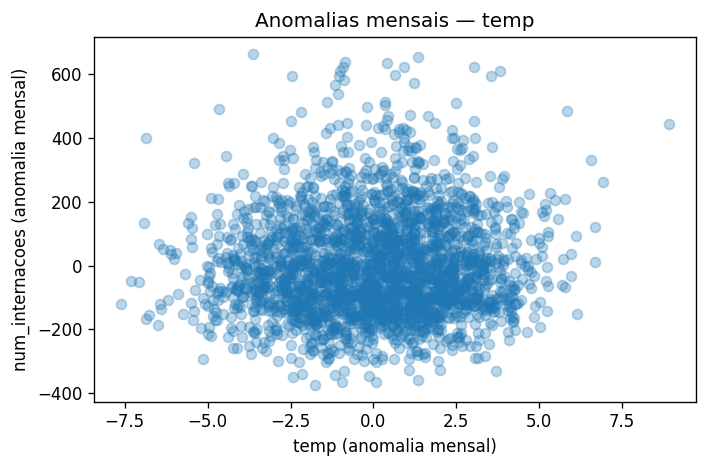

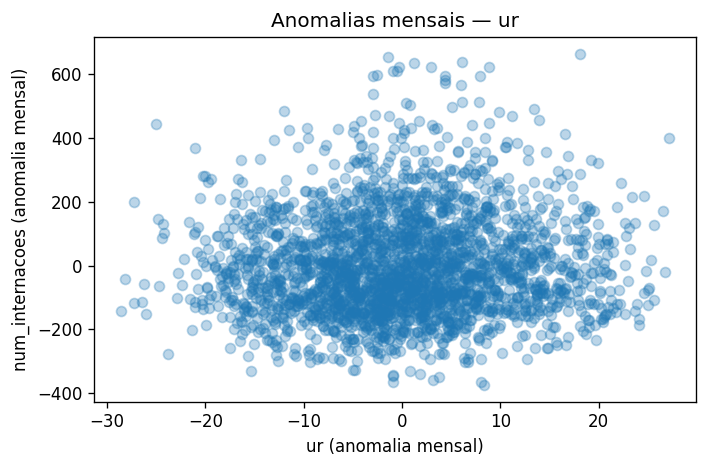

,variable,variable_label,pearson_corr_anomalia_mensal,spearman_corr_anomalia_mensal,n_obs
0,temp,Temperatura do ar,0.0443,0.0347,2534
1,ur,Umidade relativa do ar,0.0523,0.0540,2534


In [13]:

anomaly_results_rows = []

for variable, variable_label in METEOROLOGICAL_VARIABLES.items():
    anomaly_df = create_monthly_anomalies(hospitalizations_and_air, variable)

    pearson_corr, n_obs = safe_corr(
        anomaly_df[f"{TARGET_COLUMN}_anomalia_mensal"],
        anomaly_df[f"{variable}_anomalia_mensal"],
        method="pearson",
        min_obs=MIN_OBS_FOR_CORR
    )
    spearman_corr, _ = safe_corr(
        anomaly_df[f"{TARGET_COLUMN}_anomalia_mensal"],
        anomaly_df[f"{variable}_anomalia_mensal"],
        method="spearman",
        min_obs=MIN_OBS_FOR_CORR
    )

    anomaly_results_rows.append({
        "variable": variable,
        "variable_label": variable_label,
        "pearson_corr_anomalia_mensal": pearson_corr,
        "spearman_corr_anomalia_mensal": spearman_corr,
        "n_obs": n_obs,
    })

    plt.figure(figsize=(6, 4), dpi=FIG_DPI)
    plot_df = anomaly_df[[f"{variable}_anomalia_mensal", f"{TARGET_COLUMN}_anomalia_mensal"]].dropna().copy()
    plt.scatter(
        plot_df[f"{variable}_anomalia_mensal"],
        plot_df[f"{TARGET_COLUMN}_anomalia_mensal"],
        alpha=0.30
    )
    plt.title(f"Anomalias mensais — {variable}")
    plt.xlabel(f"{variable} (anomalia mensal)")
    plt.ylabel(f"{TARGET_COLUMN} (anomalia mensal)")
    plt.tight_layout()
    plt.show()

anomaly_results_df = pd.DataFrame(anomaly_results_rows)
display(anomaly_results_df.round(4))


## 14. Interação entre temperatura e umidade relativa

Nesta etapa, investigamos se a combinação de **temperatura baixa** e **umidade baixa** está associada a um comportamento diferente da série de internações.


,temp_baixa,ur_baixa,frio_e_seco,n_obs,media_internacoes,mediana_internacoes,media_temp,media_ur
0,False,False,False,2029,373.218,337.0,26.227,71.218
1,False,True,False,251,321.311,312.0,29.920,52.038
2,True,False,False,251,403.602,377.0,20.633,77.188
3,True,True,True,3,270.667,299.0,20.465,54.257


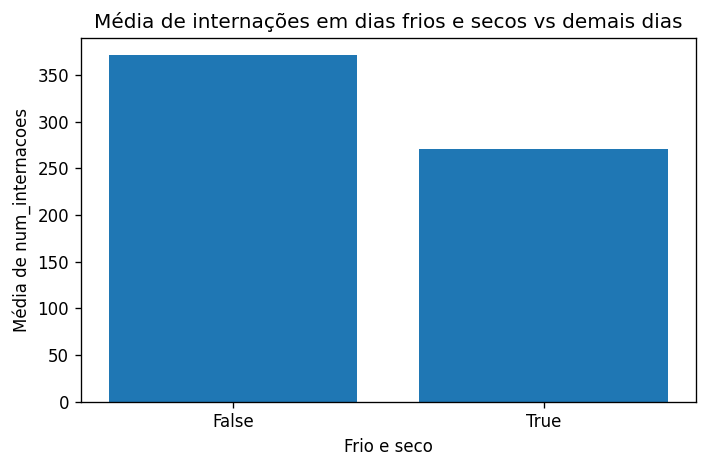

In [14]:

interaction_df = hospitalizations_and_air[
    [STANDARD_DATE_COLUMN, TARGET_COLUMN, "temp", "ur"]
].dropna().copy()

temp_threshold = interaction_df["temp"].quantile(EXTREME_QUANTILE)
ur_threshold = interaction_df["ur"].quantile(EXTREME_QUANTILE)

interaction_df["temp_baixa"] = interaction_df["temp"] <= temp_threshold
interaction_df["ur_baixa"] = interaction_df["ur"] <= ur_threshold
interaction_df["frio_e_seco"] = interaction_df["temp_baixa"] & interaction_df["ur_baixa"]

interaction_summary = (
    interaction_df
    .groupby(["temp_baixa", "ur_baixa", "frio_e_seco"])
    .agg(
        n_obs=(TARGET_COLUMN, "size"),
        media_internacoes=(TARGET_COLUMN, "mean"),
        mediana_internacoes=(TARGET_COLUMN, "median"),
        media_temp=("temp", "mean"),
        media_ur=("ur", "mean"),
    )
    .reset_index()
)

display(interaction_summary.round(3))

plt.figure(figsize=(6, 4), dpi=FIG_DPI)
plot_df = (
    interaction_df
    .groupby("frio_e_seco")[TARGET_COLUMN]
    .mean()
    .reset_index()
)
plt.bar(plot_df["frio_e_seco"].astype(str), plot_df[TARGET_COLUMN])
plt.title("Média de internações em dias frios e secos vs demais dias")
plt.xlabel("Frio e seco")
plt.ylabel(f"Média de {TARGET_COLUMN}")
plt.tight_layout()
plt.show()


## 15. Síntese automática dos achados exploratórios

In [15]:

synthesis_lines = []

for variable, variable_label in METEOROLOGICAL_VARIABLES.items():
    best_text = summarize_best_results(analysis_results[variable]["results_df"], variable_label)

    seasonal_valid = seasonal_corr_df[seasonal_corr_df["variable"] == variable].dropna(subset=["pearson_corr"])
    if not seasonal_valid.empty:
        best_season_row = seasonal_valid.iloc[seasonal_valid["pearson_corr"].abs().argmax()]
        seasonal_text = (
            f"Entre as estações, a maior correlação absoluta para {variable_label.lower()} "
            f"apareceu no **{best_season_row['estacao_ano']}** "
            f"({best_season_row['pearson_corr']:.3f})."
        )
    else:
        seasonal_text = f"Não houve observações suficientes para correlação por estação em {variable_label.lower()}."

    anomaly_row = anomaly_results_df.loc[anomaly_results_df["variable"] == variable].iloc[0]
    anomaly_text = (
        f"A correlação com **anomalias mensais** foi "
        f"{anomaly_row['pearson_corr_anomalia_mensal']:.3f} em Pearson e "
        f"{anomaly_row['spearman_corr_anomalia_mensal']:.3f} em Spearman."
    )

    synthesis_lines.append(f"- {best_text} {seasonal_text} {anomaly_text}")

display(Markdown("## Resumo interpretativo"))
display(Markdown("\n".join(synthesis_lines)))


## Resumo interpretativo

- Para **Temperatura do ar**, a maior correlação absoluta de Pearson apareceu em **janela = 14, shift = 1**, com correlação **negativa** de **-0.304** (n = 2494). Entre as estações, a maior correlação absoluta para temperatura do ar apareceu no **Outono** (-0.270). A correlação com **anomalias mensais** foi 0.044 em Pearson e 0.035 em Spearman.
- Para **Umidade relativa do ar**, a maior correlação absoluta de Pearson apareceu em **janela = 60, shift = 1**, com correlação **positiva** de **0.394** (n = 2356). Entre as estações, a maior correlação absoluta para umidade relativa do ar apareceu no **Outono** (0.169). A correlação com **anomalias mensais** foi 0.052 em Pearson e 0.054 em Spearman.

## 16. Recomendação de features para modelagem

Com base nos resultados para as variáveis meteorológicas, as principais features recomendadas são:

- `temp_ma_14d_shift_1d`: média móvel de 14 dias com shift de 1 dia, resumindo a exposição entre `t-14` e `t-1`. Foi a combinação com maior sinal para temperatura do ar (`Pearson = -0.304`) e sugere que o efeito mais relevante aparece no acúmulo recente, sem incluir o dia da internação.
- `ur_ma_60d_shift_1d`: média móvel de 60 dias com shift de 1 dia, resumindo a exposição entre `t-60` e `t-1`. Foi a combinação com maior sinal para umidade relativa do ar (`Pearson = 0.394`) e sugere um efeito acumulado mais longo do que o observado para temperatura.

Não recomendo criar outras features meteorológicas neste momento, porque os demais sinais tenderam a ser mais fracos ou relativamente próximos dessas duas representações. A interação `frio_e_seco` não parece forte o suficiente para justificar uma feature específica por enquanto, especialmente porque houve pouquíssimas observações nessa combinação extrema.

Como as correlações com anomalias mensais ficaram muito baixas para as duas variáveis, o ganho dessas features parece estar mais ligado ao padrão sazonal e ao acúmulo temporal do que a desvios mensais isolados. Vale mantê-las como candidatas importantes, mas comparando seu ganho com os poluentes nas etapas seguintes.
